# Imports and Configuration


In [1]:

import os
import copy
import math
import random
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
print("GPU    :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


Device : cuda
GPU    : NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:

# =========================
# Config
# =========================
DATA_DIR = r"D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset" 
IMG_SIZE = 224
GAN_IMG_SIZE = 64

BATCH_SIZE = 32
NUM_WORKERS = 0   

BASELINE_EPOCHS = 8
EXTRA_EPOCHS = 5

LR_CNN = 1e-3
LR_GAN = 2e-4
LATENT_DIM = 100
GAN_EPOCHS = 60
N_SYNTHETIC = 800            # how many synthetic images to add
BOTTOM_K_MINORITY = 2        # weak class chosen only among smallest train classes

CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
FOLDER_NAMES = {
    "COVID": "COVID",
    "Lung_Opacity": "Lung_Opacity",
    "Normal": "Normal",
    "Viral Pneumonia": "Viral Pneumonia",
}
assert os.path.exists(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"
print("Dataset path OK")


Dataset path OK


# Dataset Loading and Exploration

In [3]:
class ChestXrayDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

gan_transform = transforms.Compose([
    transforms.Resize((GAN_IMG_SIZE, GAN_IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

all_samples = []
for cls_name, folder in FOLDER_NAMES.items():
    img_dir = os.path.join(DATA_DIR, folder, "images")
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(".png")]
    label = CLASS_TO_IDX[cls_name]
    for fname in files:
        all_samples.append((os.path.join(img_dir, fname), label))

all_labels = np.array([label for _, label in all_samples])
print("Total images:", len(all_samples))
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:20s}: {(all_labels == i).sum()}")


Total images: 21165
COVID               : 3616
Lung_Opacity        : 6012
Normal              : 10192
Viral Pneumonia     : 1345


# Train–Validation–Test Split

In [4]:

# =========================
# Train / val / test split
# =========================
indices = np.arange(len(all_samples))

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    all_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels,
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

train_samples = [all_samples[i] for i in train_idx]
val_samples = [all_samples[i] for i in val_idx]
test_samples = [all_samples[i] for i in test_idx]

train_dataset = ChestXrayDataset(train_samples, transform=base_transform)
val_dataset   = ChestXrayDataset(val_samples, transform=base_transform)
test_dataset  = ChestXrayDataset(test_samples, transform=base_transform)

def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

train_loader = make_loader(train_dataset, shuffle=True)
val_loader   = make_loader(val_dataset, shuffle=False)
test_loader  = make_loader(test_dataset, shuffle=False)

print("Train:", len(train_dataset), "| Val:", len(val_dataset), "| Test:", len(test_dataset))


Train: 16932 | Val: 2116 | Test: 2117


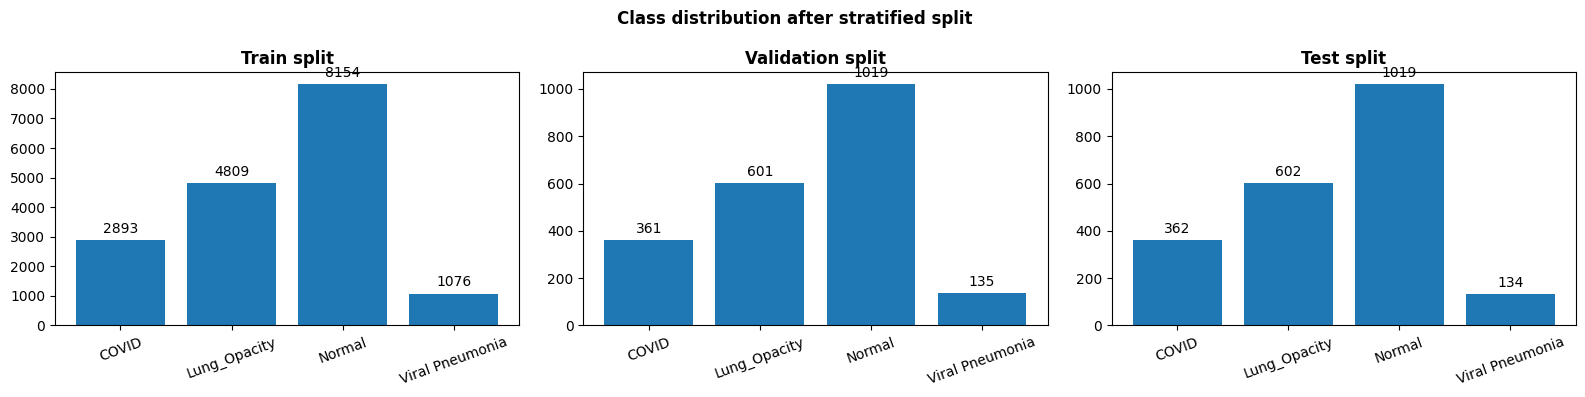

In [5]:

# =========================
# Visualize split distributions
# =========================
def count_labels(samples):
    cnt = Counter([label for _, label in samples])
    return [cnt[i] for i in range(len(CLASS_NAMES))]

train_counts = count_labels(train_samples)
val_counts   = count_labels(val_samples)
test_counts  = count_labels(test_samples)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, counts, title in zip(
    axes,
    [train_counts, val_counts, test_counts],
    ["Train split", "Validation split", "Test split"]
):
    bars = ax.bar(CLASS_NAMES, counts)
    ax.bar_label(bars, padding=3)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Class distribution after stratified split", fontweight="bold")
plt.tight_layout()
plt.show()


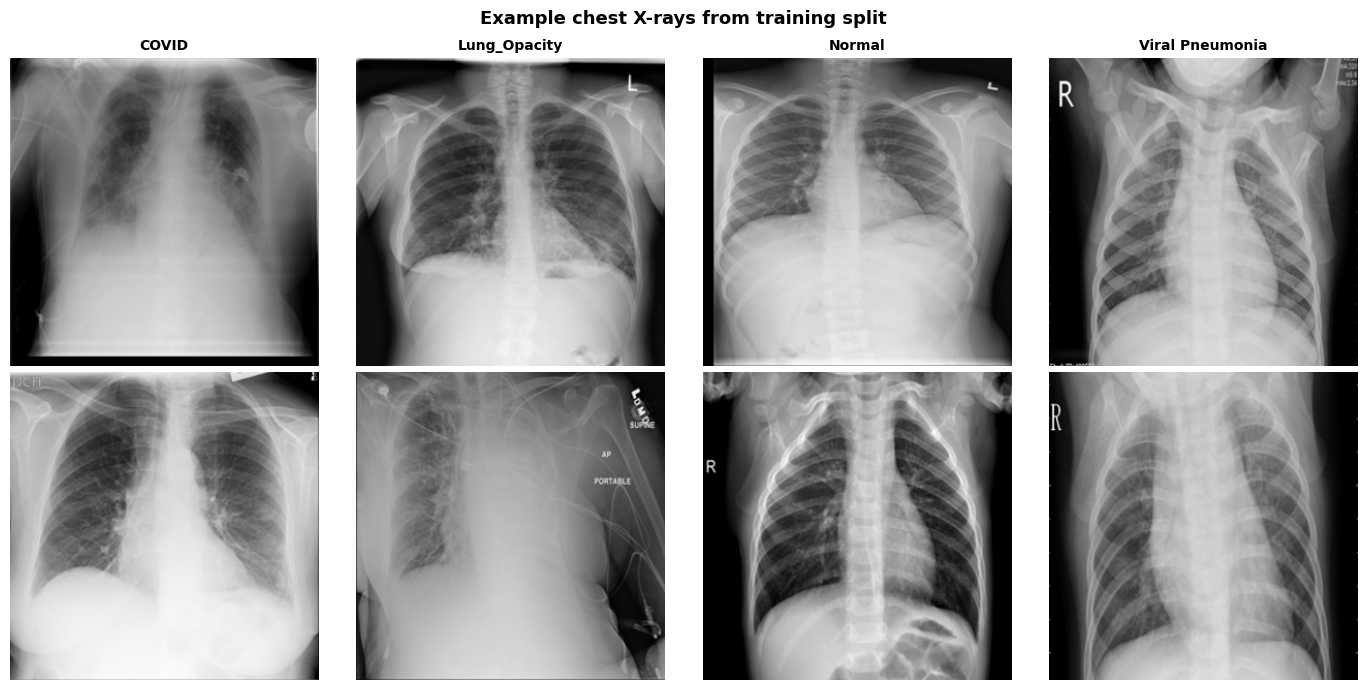

In [6]:

# =========================
# Show sample images
# =========================
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, cls_name in enumerate(CLASS_NAMES):
    sample_paths = [p for p, y in train_samples if y == CLASS_TO_IDX[cls_name]][:2]
    for row, path in enumerate(sample_paths):
        img = Image.open(path).convert("L")
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].axis("off")
        if row == 0:
            axes[row][col].set_title(cls_name, fontsize=10, fontweight="bold")

plt.suptitle("Example chest X-rays from training split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# Model Architecture

In [7]:

# =========================
# Model
# =========================
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for p in backbone.parameters():
            p.requires_grad = False
        backbone.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

model = ResNetClassifier(len(CLASS_NAMES))
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", f"{trainable:,}")


Trainable params: 132,356


# Baseline Model Training

In [8]:

# =========================
# Training + evaluation helpers
# =========================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        log_probs = torch.nn.functional.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        target_log_probs = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        target_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = -((1.0 - target_probs) ** self.gamma) * target_log_probs
        if self.alpha is not None:
            loss = loss * self.alpha.to(logits.device).gather(0, targets)
        return loss.mean()


def get_class_weights_from_samples(samples, n_classes):
    labels = torch.tensor([label for _, label in samples], dtype=torch.long)
    counts = torch.bincount(labels, minlength=n_classes).float()
    weights = counts.sum() / (n_classes * counts)
    return weights

def train_classifier(model, train_loader, val_loader, train_samples_for_weights,
                     epochs, lr, title="Model", loss_name="weighted_ce", focal_gamma=2.0):
    model = model.to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    weights = get_class_weights_from_samples(train_samples_for_weights, len(CLASS_NAMES)).to(device)
    if loss_name == "weighted_ce":
        criterion = nn.CrossEntropyLoss(weight=weights)
    elif loss_name == "focal":
        criterion = FocalLoss(gamma=focal_gamma, alpha=weights)
    else:
        raise ValueError(f"Unknown loss_name: {loss_name}")

    best_state = None
    best_val_f1 = -1.0
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        val_metrics = evaluate_model(model, val_loader)
        history.append({
            "epoch": epoch + 1,
            "train_loss": running_loss / len(train_loader),
            "train_acc": 100.0 * correct / total,
            "val_acc": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        })

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{title} | Epoch {epoch+1}/{epochs} | "
            f"train_loss={history[-1]['train_loss']:.3f} | "
            f"train_acc={history[-1]['train_acc']:.1f}% | "
            f"val_acc={val_metrics['accuracy']:.1f}% | "
            f"val_macro_f1={val_metrics['macro_f1']:.3f}"
        )

    model.load_state_dict(best_state)
    return model, history

def predict_all(model, loader):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds = model(images).argmax(1).cpu().numpy()
            all_pred.extend(preds.tolist())
            all_true.extend(labels.numpy().tolist())
    return np.array(all_true), np.array(all_pred)

def evaluate_model(model, loader):
    y_true, y_pred = predict_all(model, loader)
    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, digits=3, output_dict=True, zero_division=0
    )
    per_class_recall = {cls: report[cls]["recall"] * 100 for cls in CLASS_NAMES}
    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "macro_f1": f1_score(y_true, y_pred, average="macro") ,
        "report": report,
        "per_class_recall": per_class_recall,
        "y_true": y_true,
        "y_pred": y_pred,
    }

def print_metrics(name, metrics):
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Accuracy : {metrics['accuracy']:.2f}%")
    print(f"Macro F1 : {metrics['macro_f1']:.4f}")
    print("Per-class recall:")
    for cls in CLASS_NAMES:
        print(f"  {cls:20s}: {metrics['per_class_recall'][cls]:6.2f}%")


In [9]:

# =========================
# Baseline training
# =========================
baseline_model = ResNetClassifier(num_classes=len(CLASS_NAMES))
baseline_model, baseline_history = train_classifier(
    baseline_model,
    train_loader,
    val_loader,
    train_samples_for_weights=train_samples,
    epochs=BASELINE_EPOCHS,
    lr=LR_CNN,
    title="Baseline"
)

baseline_val_metrics = evaluate_model(baseline_model, val_loader)
print_metrics("Baseline validation metrics", baseline_val_metrics)


Baseline | Epoch 1/8 | train_loss=0.610 | train_acc=72.9% | val_acc=81.6% | val_macro_f1=0.812
Baseline | Epoch 2/8 | train_loss=0.458 | train_acc=79.9% | val_acc=82.5% | val_macro_f1=0.828
Baseline | Epoch 3/8 | train_loss=0.412 | train_acc=81.2% | val_acc=80.3% | val_macro_f1=0.817
Baseline | Epoch 4/8 | train_loss=0.392 | train_acc=82.1% | val_acc=81.8% | val_macro_f1=0.819
Baseline | Epoch 5/8 | train_loss=0.382 | train_acc=82.7% | val_acc=85.2% | val_macro_f1=0.850
Baseline | Epoch 6/8 | train_loss=0.352 | train_acc=84.2% | val_acc=84.4% | val_macro_f1=0.851
Baseline | Epoch 7/8 | train_loss=0.349 | train_acc=84.0% | val_acc=83.4% | val_macro_f1=0.845
Baseline | Epoch 8/8 | train_loss=0.344 | train_acc=84.4% | val_acc=86.0% | val_macro_f1=0.866

Baseline validation metrics
---------------------------
Accuracy : 86.01%
Macro F1 : 0.8660
Per-class recall:
  COVID               :  88.09%
  Lung_Opacity        :  79.87%
  Normal              :  87.63%
  Viral Pneumonia     :  95.56%


# Weak Class Identification (Validation-Based)

In [10]:

# =========================
# Choose weak class correctly
# - ONLY use validation set
# - ONLY choose among minority classes
# =========================
train_count_map = {CLASS_NAMES[i]: train_counts[i] for i in range(len(CLASS_NAMES))}
minority_candidates = sorted(CLASS_NAMES, key=lambda c: train_count_map[c])[:BOTTOM_K_MINORITY]

print("Minority candidates:", minority_candidates)

candidate_recalls = {cls: baseline_val_metrics["per_class_recall"][cls] for cls in minority_candidates}
WEAK_CLASS_NAME = min(candidate_recalls, key=candidate_recalls.get)
WEAK_CLASS = CLASS_TO_IDX[WEAK_CLASS_NAME]

print("Validation recall among minority candidates:")
for cls in minority_candidates:
    print(f"  {cls:20s}: {candidate_recalls[cls]:6.2f}%")

print(f"\nChosen weak class for expansion: {WEAK_CLASS_NAME}")


Minority candidates: ['Viral Pneumonia', 'COVID']
Validation recall among minority candidates:
  Viral Pneumonia     :  95.56%
  COVID               :  88.09%

Chosen weak class for expansion: COVID


In [11]:

# =========================
# Continue-training control
# same baseline checkpoint, same extra epochs, no new data
# =========================
continued_model = copy.deepcopy(baseline_model)
continued_model, continued_history = train_classifier(
    continued_model,
    train_loader,
    val_loader,
    train_samples_for_weights=train_samples,
    epochs=EXTRA_EPOCHS,
    lr=LR_CNN * 0.5,
    title="ContinueOnly"
)

continued_val_metrics = evaluate_model(continued_model, val_loader)
print_metrics("Continue-only validation metrics", continued_val_metrics)


ContinueOnly | Epoch 1/5 | train_loss=0.306 | train_acc=86.2% | val_acc=86.6% | val_macro_f1=0.871
ContinueOnly | Epoch 2/5 | train_loss=0.292 | train_acc=86.4% | val_acc=86.7% | val_macro_f1=0.874
ContinueOnly | Epoch 3/5 | train_loss=0.292 | train_acc=86.4% | val_acc=84.3% | val_macro_f1=0.854
ContinueOnly | Epoch 4/5 | train_loss=0.281 | train_acc=86.9% | val_acc=86.4% | val_macro_f1=0.868
ContinueOnly | Epoch 5/5 | train_loss=0.271 | train_acc=87.0% | val_acc=87.0% | val_macro_f1=0.872

Continue-only validation metrics
--------------------------------
Accuracy : 86.72%
Macro F1 : 0.8738
Per-class recall:
  COVID               :  90.30%
  Lung_Opacity        :  80.87%
  Normal              :  87.63%
  Viral Pneumonia     :  96.30%


In [12]:

# =========================
# Stronger imbalance baseline: Focal Loss
# =========================
focal_model = copy.deepcopy(baseline_model)
focal_model, focal_history = train_classifier(
    focal_model,
    train_loader,
    val_loader,
    train_samples_for_weights=train_samples,
    epochs=EXTRA_EPOCHS,
    lr=LR_CNN * 0.5,
    title="FocalLoss",
    loss_name="focal",
    focal_gamma=2.0,
)

focal_val_metrics = evaluate_model(focal_model, val_loader)
print_metrics("Focal-loss validation metrics", focal_val_metrics)


FocalLoss | Epoch 1/5 | train_loss=0.121 | train_acc=85.2% | val_acc=87.8% | val_macro_f1=0.885
FocalLoss | Epoch 2/5 | train_loss=0.111 | train_acc=85.6% | val_acc=84.5% | val_macro_f1=0.845
FocalLoss | Epoch 3/5 | train_loss=0.104 | train_acc=86.5% | val_acc=85.0% | val_macro_f1=0.857
FocalLoss | Epoch 4/5 | train_loss=0.108 | train_acc=85.9% | val_acc=86.3% | val_macro_f1=0.866
FocalLoss | Epoch 5/5 | train_loss=0.104 | train_acc=86.4% | val_acc=85.4% | val_macro_f1=0.866

Focal-loss validation metrics
-----------------------------
Accuracy : 87.81%
Macro F1 : 0.8854
Per-class recall:
  COVID               :  88.37%
  Lung_Opacity        :  80.87%
  Normal              :  90.78%
  Viral Pneumonia     :  94.81%


# Classical Oversampling of Minority Class

In [13]:

# =========================
# Real-image oversampling control
# duplicate weak-class REAL training images
# =========================
weak_train_samples = [s for s in train_samples if s[1] == WEAK_CLASS]
extra_real_samples = [random.choice(weak_train_samples) for _ in range(N_SYNTHETIC)]
oversampled_train_samples = train_samples + extra_real_samples

oversampled_train_dataset = ChestXrayDataset(oversampled_train_samples, transform=base_transform)
oversampled_train_loader = make_loader(oversampled_train_dataset, shuffle=True)

print("Original train size   :", len(train_samples))
print("Oversampled train size:", len(oversampled_train_samples))
print("Added real duplicates :", len(extra_real_samples))

oversample_model = copy.deepcopy(baseline_model)
oversample_model, oversample_history = train_classifier(
    oversample_model,
    oversampled_train_loader,
    val_loader,
    train_samples_for_weights=oversampled_train_samples,
    epochs=EXTRA_EPOCHS,
    lr=LR_CNN * 0.5,
    title="RealOversample"
)

oversample_val_metrics = evaluate_model(oversample_model, val_loader)
print_metrics("Real-oversampling validation metrics", oversample_val_metrics)


Original train size   : 16932
Oversampled train size: 17732
Added real duplicates : 800
RealOversample | Epoch 1/5 | train_loss=0.305 | train_acc=86.2% | val_acc=86.1% | val_macro_f1=0.862
RealOversample | Epoch 2/5 | train_loss=0.292 | train_acc=86.4% | val_acc=86.7% | val_macro_f1=0.873
RealOversample | Epoch 3/5 | train_loss=0.290 | train_acc=86.8% | val_acc=85.7% | val_macro_f1=0.863
RealOversample | Epoch 4/5 | train_loss=0.277 | train_acc=86.7% | val_acc=85.3% | val_macro_f1=0.857
RealOversample | Epoch 5/5 | train_loss=0.279 | train_acc=87.1% | val_acc=86.3% | val_macro_f1=0.873

Real-oversampling validation metrics
------------------------------------
Accuracy : 86.72%
Macro F1 : 0.8734
Per-class recall:
  COVID               :  91.97%
  Lung_Opacity        :  78.04%
  Normal              :  88.91%
  Viral Pneumonia     :  94.81%


# GAN-Based Synthetic Data Augmentation


In [14]:

# =========================
# DCGAN
# =========================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),   # 4x4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),   # 8x8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),   # 16x16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),    # 32x32
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()                              # 64x64
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),                 # 32x32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),  # 16x16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),  # 8x8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),  # 4x4
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)


In [15]:

# =========================
# Train DCGAN on weak class ONLY
# =========================
weak_gan_samples = [s for s in train_samples if s[1] == WEAK_CLASS]
weak_gan_dataset = ChestXrayDataset(weak_gan_samples, transform=gan_transform)
weak_gan_loader = make_loader(weak_gan_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Training GAN on weak class: {WEAK_CLASS_NAME}")
print("Weak-class training images:", len(weak_gan_dataset))

def train_dcgan(loader, epochs):
    G = Generator().to(device)
    D = Discriminator().to(device)

    opt_G = optim.Adam(G.parameters(), lr=LR_GAN, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR_GAN * 0.5, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        for images, _ in loader:
            images = images.to(device)
            b = images.size(0)

            real_targets = torch.ones(b, device=device) * 0.9
            fake_targets = torch.zeros(b, device=device)

            # D step
            opt_D.zero_grad()
            d_real = criterion(D(images), real_targets)

            noise = torch.randn(b, LATENT_DIM, 1, 1, device=device)
            fake_images = G(noise)
            d_fake = criterion(D(fake_images.detach()), fake_targets)

            d_loss = d_real + d_fake
            d_loss.backward()
            opt_D.step()

            # G step
            opt_G.zero_grad()
            noise = torch.randn(b, LATENT_DIM, 1, 1, device=device)
            generated = G(noise)
            g_loss = criterion(D(generated), real_targets)
            g_loss.backward()
            opt_G.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | D_loss={d_loss.item():.3f} | G_loss={g_loss.item():.3f}")

    return G

generator = train_dcgan(weak_gan_loader, GAN_EPOCHS)


Training GAN on weak class: COVID
Weak-class training images: 2893
Epoch  10/60 | D_loss=1.491 | G_loss=0.597
Epoch  20/60 | D_loss=0.584 | G_loss=2.240
Epoch  30/60 | D_loss=0.958 | G_loss=1.903
Epoch  40/60 | D_loss=0.670 | G_loss=1.235
Epoch  50/60 | D_loss=0.809 | G_loss=3.229
Epoch  60/60 | D_loss=0.685 | G_loss=2.280


Synthetic images: 800


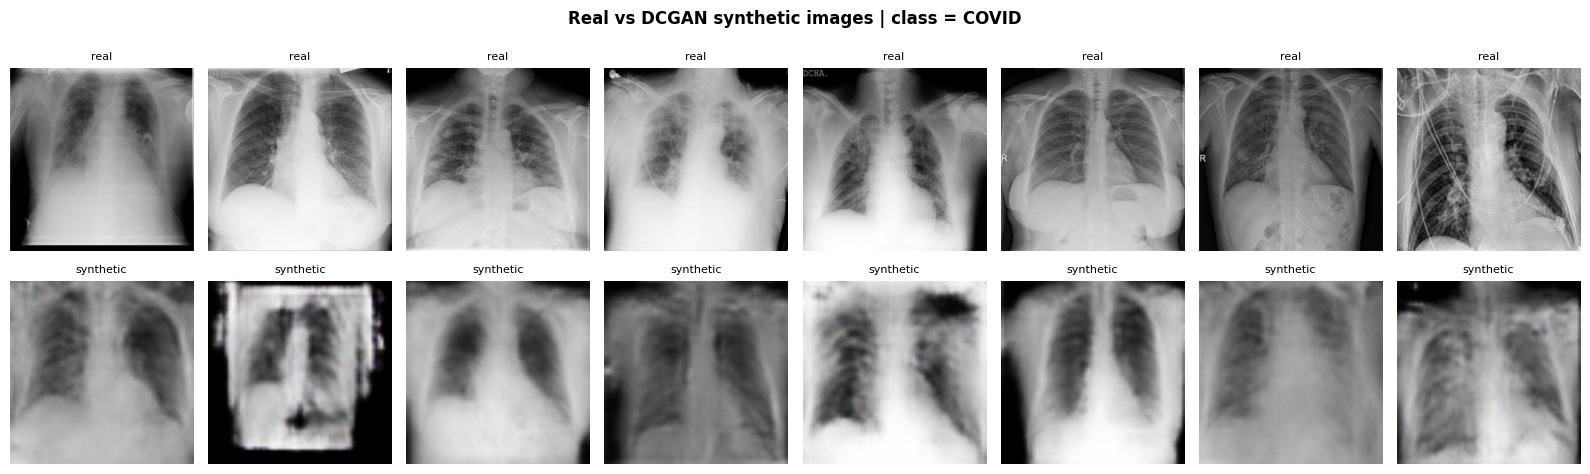

In [16]:

# =========================
# Generate synthetic weak-class images
# =========================
upsample_to_classifier = transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True)

def generate_synthetic(generator, n):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n, LATENT_DIM, 1, 1, device=device)
        fake = generator(noise).cpu()
    fake = torch.stack([upsample_to_classifier(img) for img in fake])
    labels = torch.full((n,), WEAK_CLASS, dtype=torch.long)
    return fake, labels

syn_images, syn_labels = generate_synthetic(generator, N_SYNTHETIC)
print("Synthetic images:", len(syn_images))

# real vs fake quick visual check
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

real_paths = [p for p, y in weak_gan_samples[:8]]
for i in range(8):
    real_img = Image.open(real_paths[i]).convert("L")
    axes[0, i].imshow(real_img, cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("real", fontsize=8)

    fake_img = syn_images[i].permute(1, 2, 0).numpy()
    fake_img = (fake_img * 0.5 + 0.5).clip(0, 1)
    axes[1, i].imshow(fake_img, cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("synthetic", fontsize=8)

plt.suptitle(f"Real vs DCGAN synthetic images | class = {WEAK_CLASS_NAME}", fontweight="bold")
plt.tight_layout()
plt.show()


In [17]:

syn_dataset = TensorDataset(syn_images, syn_labels.long())
gan_train_dataset = ConcatDataset([train_dataset, syn_dataset])
gan_train_loader = DataLoader(
    gan_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

gan_weight_samples = train_samples + [("synthetic", WEAK_CLASS) for _ in range(N_SYNTHETIC)]

gan_model = copy.deepcopy(baseline_model)
gan_model, gan_history = train_classifier(
    gan_model,
    gan_train_loader,
    val_loader,
    train_samples_for_weights=gan_weight_samples,
    epochs=EXTRA_EPOCHS,
    lr=LR_CNN * 0.5,
    title="GANAugmented"
)

gan_val_metrics = evaluate_model(gan_model, val_loader)
print_metrics("GAN-augmented validation metrics", gan_val_metrics)


GANAugmented | Epoch 1/5 | train_loss=0.299 | train_acc=86.4% | val_acc=86.6% | val_macro_f1=0.876
GANAugmented | Epoch 2/5 | train_loss=0.282 | train_acc=87.0% | val_acc=87.1% | val_macro_f1=0.878
GANAugmented | Epoch 3/5 | train_loss=0.281 | train_acc=86.9% | val_acc=86.8% | val_macro_f1=0.872
GANAugmented | Epoch 4/5 | train_loss=0.274 | train_acc=87.4% | val_acc=85.4% | val_macro_f1=0.865
GANAugmented | Epoch 5/5 | train_loss=0.273 | train_acc=87.3% | val_acc=87.0% | val_macro_f1=0.876

GAN-augmented validation metrics
--------------------------------
Accuracy : 87.15%
Macro F1 : 0.8780
Per-class recall:
  COVID               :  88.92%
  Lung_Opacity        :  83.19%
  Normal              :  87.73%
  Viral Pneumonia     :  95.56%


# Final Evaluation on Test Set

In [18]:

# =========================
# Final test-set evaluation
# test is used ONLY here
# =========================
baseline_test   = evaluate_model(baseline_model, test_loader)
continued_test  = evaluate_model(continued_model, test_loader)
focal_test      = evaluate_model(focal_model, test_loader)
oversample_test = evaluate_model(oversample_model, test_loader)
gan_test        = evaluate_model(gan_model, test_loader)

summary_rows = [
    ("Baseline", baseline_test["accuracy"], baseline_test["macro_f1"], baseline_test["per_class_recall"][WEAK_CLASS_NAME]),
    ("Continue only", continued_test["accuracy"], continued_test["macro_f1"], continued_test["per_class_recall"][WEAK_CLASS_NAME]),
    ("Focal loss", focal_test["accuracy"], focal_test["macro_f1"], focal_test["per_class_recall"][WEAK_CLASS_NAME]),
    ("Real oversample", oversample_test["accuracy"], oversample_test["macro_f1"], oversample_test["per_class_recall"][WEAK_CLASS_NAME]),
    ("GAN augmented", gan_test["accuracy"], gan_test["macro_f1"], gan_test["per_class_recall"][WEAK_CLASS_NAME]),
]

print(f"Weak class used for expansion: {WEAK_CLASS_NAME}\n")
print(f"{'Method':<18} {'Accuracy':>10} {'Macro F1':>10} {WEAK_CLASS_NAME[:18]:>18}")
print("=" * 60)
for name, acc, mf1, weak_recall in summary_rows:
    print(f"{name:<18} {acc:>9.2f}% {mf1:>10.4f} {weak_recall:>17.2f}%")


Weak class used for expansion: COVID

Method               Accuracy   Macro F1              COVID
Baseline               87.10%     0.8724             88.40%
Continue only          87.58%     0.8773             91.16%
Focal loss             87.20%     0.8742             90.06%
Real oversample        87.72%     0.8806             92.54%
GAN augmented          87.67%     0.8788             90.33%


# Results and Analysis

In [19]:

# =========================
# Detailed reports
# =========================
for name, metrics in [
    ("Baseline test metrics", baseline_test),
    ("Continue-only test metrics", continued_test),
    ("Focal-loss test metrics", focal_test),
    ("Real-oversampling test metrics", oversample_test),
    ("GAN-augmented test metrics", gan_test),
]:
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(
        metrics["y_true"],
        metrics["y_pred"],
        target_names=CLASS_NAMES,
        digits=3,
        zero_division=0
    ))



Baseline test metrics
                 precision    recall  f1-score   support

          COVID      0.870     0.884     0.877       362
   Lung_Opacity      0.837     0.817     0.827       602
         Normal      0.899     0.884     0.892      1019
Viral Pneumonia      0.824     0.978     0.894       134

       accuracy                          0.871      2117
      macro avg      0.857     0.891     0.872      2117
   weighted avg      0.872     0.871     0.871      2117


Continue-only test metrics
                 precision    recall  f1-score   support

          COVID      0.855     0.912     0.882       362
   Lung_Opacity      0.853     0.811     0.831       602
         Normal      0.902     0.889     0.896      1019
Viral Pneumonia      0.839     0.970     0.900       134

       accuracy                          0.876      2117
      macro avg      0.862     0.895     0.877      2117
   weighted avg      0.876     0.876     0.875      2117


Focal-loss test metrics
      

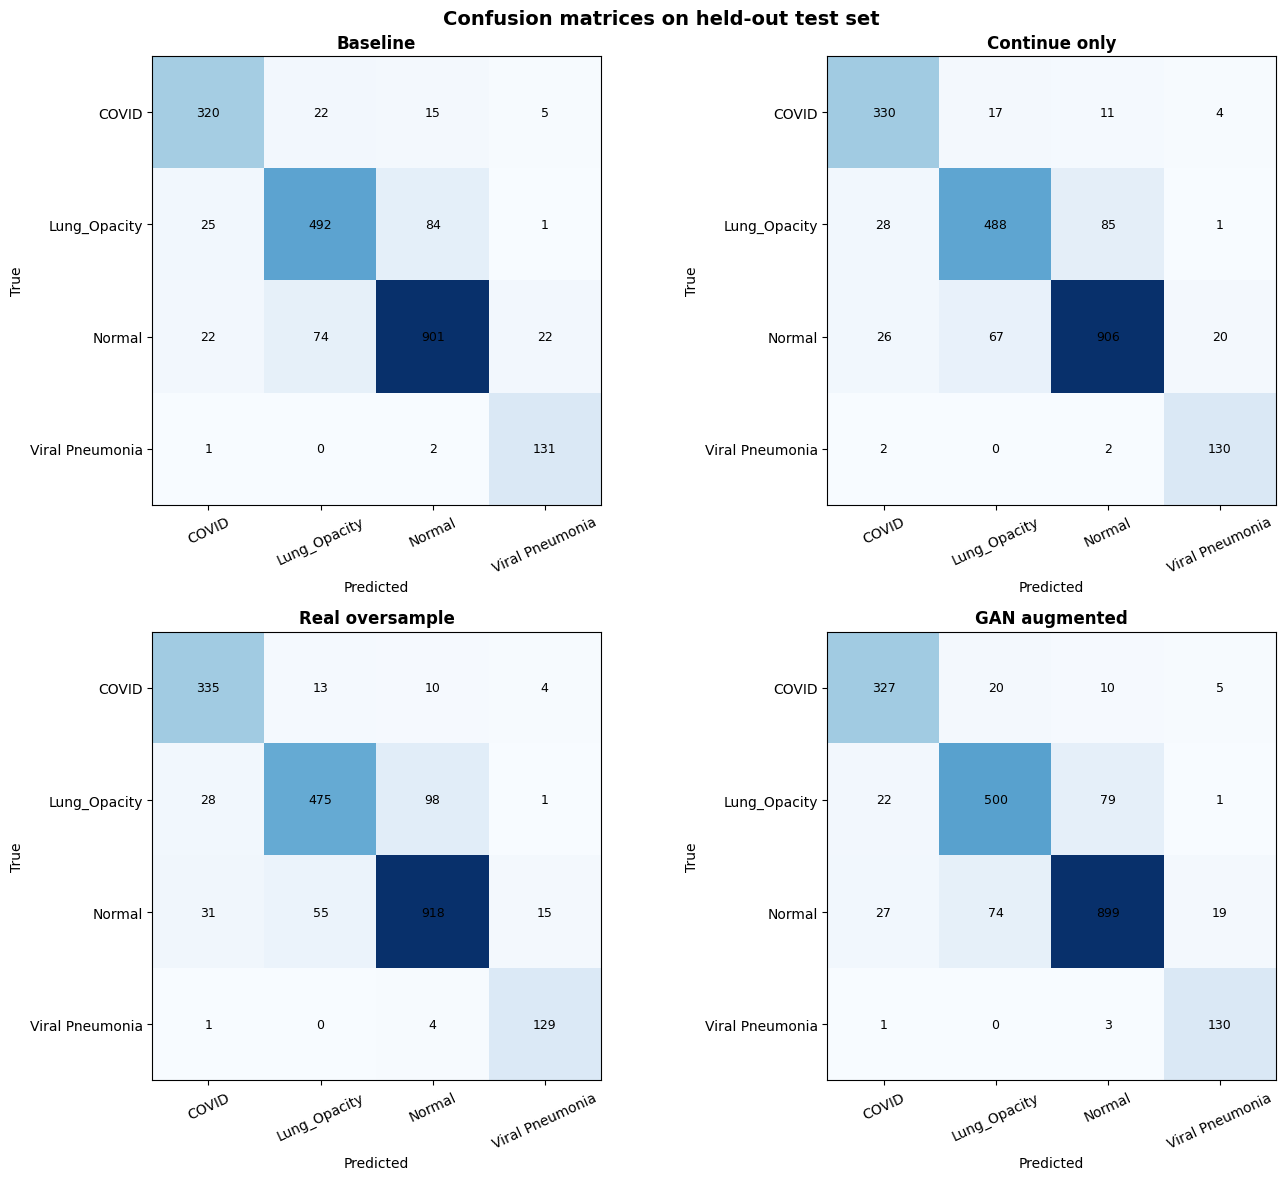

In [20]:

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
all_results = [
    ("Baseline", baseline_test),
    ("Continue only", continued_test),
    ("Real oversample", oversample_test),
    ("GAN augmented", gan_test),
]

for ax, (title, metrics) in zip(axes.flatten(), all_results):
    cm = confusion_matrix(metrics["y_true"], metrics["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=25)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=9)

plt.suptitle("Confusion matrices on held-out test set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
